# Global Alignment Kernel (GAK)

A similarity that sums over **all** pairwise alignments of two sequences ([Cuturi, 2007](https://members.cbio.mines-paristech.fr/~jvert/publi/pdf/Cuturi2007Kernel.pdf), eq. 1), computed stably in log-space and normalized. A wider RBF bandwidth keeps the off-diagonal similarities informative.

## Environment
Detect the live backend/device and whether a SYCL fast-path is available.

In [1]:
import sys, pathlib
# Make `_nbtools` and the in-repo `ksig` importable whether the notebook is
# launched from ./notebooks or from the repo root (no `pip install` needed).
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import ksig
import _nbtools as nb
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)

[2026-06-02 01:17:58,679] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /var/tmp/pbs.8519295.aurora-pbs-0001.hostmgmt.cm.aurora.alcf.anl.gov/claude-35813/tmpcw2schj_/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-02 01:18:03,460] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: xpu  |  SYCL: available  |  ksig unknown


## Deterministic input
`simulate(16, 8, 3, seed=0)` — a batch of integrated random walks (portable: the NumPy RNG is bit-identical on every machine, so the values below are reproducible on Aurora).

In [2]:
X = nb.simulate(16, 8, 3, seed=0)
print('X shape:', X.shape, '| dtype:', X.dtype)

X shape: (16, 8, 3) | dtype: float64


## Compute the kernel

```python
gak = ksig.kernels.GlobalAlignmentKernel(static_kernel=ksig.static.kernels.RBFKernel(bandwidth=5.0))
K = gak(X)
print("gram shape :", tuple(K.shape))
print("K[:3,:3]   :\n", np.round(nb.as_host(K)[:3, :3], 4))
print("diag mean  :", round(float(np.diag(nb.as_host(K)).mean()), 6))
```

**Reference output — NVIDIA H100 NVL (CuPy 14.1.0), kwargs: `static=RBF(bandwidth=5.0)  (normalized, log-space)`:**

```text
gram shape : (16, 16)
K[:3,:3]   :
 [[1.     0.5575 0.535 ]
 [0.5575 1.     0.7601]
 [0.535  0.7601 1.    ]]
diag mean  : 1.0
```

Running the next cell on the target machine should reproduce this to ~1e-8 in
float64 (`diag == 1` exactly when `normalize=True`).

In [3]:
gak = ksig.kernels.GlobalAlignmentKernel(static_kernel=ksig.static.kernels.RBFKernel(bandwidth=5.0))
K = gak(X)
print("gram shape :", tuple(K.shape))
print("K[:3,:3]   :\n", np.round(nb.as_host(K)[:3, :3], 4))
print("diag mean  :", round(float(np.diag(nb.as_host(K)).mean()), 6))

gram shape : (16, 16)
K[:3,:3]   :
 [[1.     0.5575 0.535 ]
 [0.5575 1.     0.7601]
 [0.535  0.7601 1.    ]]
diag mean  : 1.0


## Scaling — green = CUDA reference, blue = this machine

The cell below sweeps **sequence length L  (n=32, d=3)** and times each point on whatever backend
is live, then overlays:

* 🟩 **green** — the frozen reference measured on **NVIDIA H100 NVL** (`cuda_reference.json`),
* 🟦 **blue** — what *this* machine computes now (torch-native on Aurora XPU / CUDA / CPU),
* 🟧 **orange** — the **SYCL** fast-path (this kernel dispatches to `ksig._sycl`),
  drawn **only if** a build is present (`nb.sycl_available()`); the blue curve is
  the same kernel with SYCL forced off, so blue-vs-orange is the head-to-head.

The grid and the knobs at the top of the cell are **tunable** — they default to
the reference grid so blue lines up with green; widen them to push the frontier.

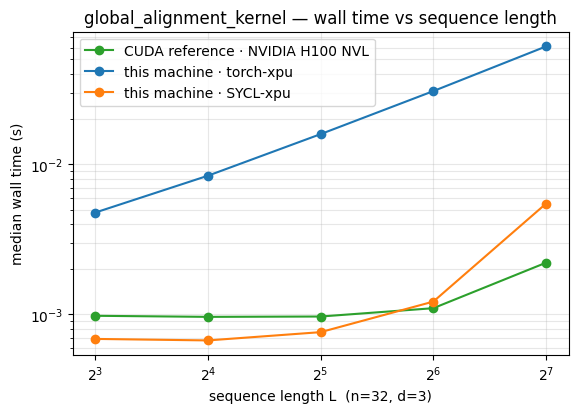

In [4]:
# --- tunable knobs (default to the CUDA-reference grid) ---------------------
L_GRID = [8, 16, 32, 64, 128]          # sequence lengths to sweep
N, D   = 32, 3                 # fixed batch size / channels
REPS   = 5
BANDWIDTH = 5.0                   # RBF bandwidth of the static kernel

def time_one(L):
    Xs = nb.simulate(N, L, D, seed=1)
    k = ksig.kernels.GlobalAlignmentKernel(static_kernel=ksig.static.kernels.RBFKernel(bandwidth=BANDWIDTH))
    return nb.timeit(lambda: k(Xs), reps=REPS, device=ENV["device"])

# BLUE = torch-native baseline: force the SYCL fast-path OFF so this curve is
# the eager wavefront (on XPU, SYCL auto-engages by default, which would make
# blue == orange). A no-op where SYCL is absent.
nb.enable_sycl(False)
times = [time_one(L) for L in L_GRID]

# ORANGE = SYCL fast-path. Drawn ONLY when a SYCL build is available; run the
# same sweep with the fast-path on, then restore the torch-native default.
sycl_times = None
if nb.sycl_available():
    nb.enable_sycl(True)
    sycl_times = [time_one(L) for L in L_GRID]
    nb.enable_sycl(False)

nb.scaling_plot(L_GRID, times, "global_alignment_kernel", sycl_seconds=sycl_times,
                title="global_alignment_kernel — wall time vs sequence length");